# **Week 4 : GNN / Attention Modelling and Geospatial Dashboard**

In [1]:
pip install shap joblib

In [2]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import(mean_squared_error,mean_absolute_error,r2_score,mean_absolute_percentage_error)

from xgboost import XGBRegressor

In [4]:
df = pd.read_csv("week3_AB_NYC_2019.zip")

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,availability_365,distance_to_center,availability_ratio,review_density,price_per_night,avg_neighbor_price,avg_neighbor_reviews,avg_neighbor_availability,avg_neighbor_minimum_nights,neighbor_density
0,2539,Clean & quiet apt home by the park,2787,John,1,107,40.64749,-73.97237,1,149,...,365,12.337898,1.000000,4.500000,74.500000,151.4,43.8,131.0,10.0,5
1,2595,Skylit Midtown Castle,2845,Jennifer,2,126,40.75362,-73.98377,0,225,...,355,0.508366,0.972603,22.500000,112.500000,190.8,35.6,166.6,2.6,5
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,2,93,40.80902,-73.94190,1,150,...,365,6.757240,1.000000,0.000000,37.500000,183.0,20.2,103.6,12.6,5
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,1,41,40.68514,-73.95976,0,89,...,194,8.387034,0.531507,135.000000,44.500000,124.8,13.6,59.6,3.8,5
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,2,61,40.79851,-73.94399,0,80,...,0,5.701496,0.000000,0.818182,7.272727,160.0,6.0,203.6,4.2,5


**Select Features :**






In [5]:
features = ["latitude","longitude","minimum_nights","number_of_reviews","reviews_per_month","availability_365","distance_to_center","avg_neighbor_price","avg_neighbor_reviews","avg_neighbor_availability","avg_neighbor_minimum_nights"]

X = df[features]

y = df["price"]

In [6]:
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,availability_365,distance_to_center,availability_ratio,review_density,price_per_night,avg_neighbor_price,avg_neighbor_reviews,avg_neighbor_availability,avg_neighbor_minimum_nights,neighbor_density
0,2539,Clean & quiet apt home by the park,2787,John,1,107,40.64749,-73.97237,1,149,...,365,12.337898,1.000000,4.500000,74.500000,151.4,43.8,131.0,10.0,5
1,2595,Skylit Midtown Castle,2845,Jennifer,2,126,40.75362,-73.98377,0,225,...,355,0.508366,0.972603,22.500000,112.500000,190.8,35.6,166.6,2.6,5
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,2,93,40.80902,-73.94190,1,150,...,365,6.757240,1.000000,0.000000,37.500000,183.0,20.2,103.6,12.6,5
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,1,41,40.68514,-73.95976,0,89,...,194,8.387034,0.531507,135.000000,44.500000,124.8,13.6,59.6,3.8,5
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,2,61,40.79851,-73.94399,0,80,...,0,5.701496,0.000000,0.818182,7.272727,160.0,6.0,203.6,4.2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45882,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,1,13,40.67853,-73.94995,1,70,...,9,9.330755,0.024658,0.000000,23.333333,91.0,48.4,95.8,8.2,5
45883,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,1,28,40.70184,-73.93317,1,40,...,36,7.644594,0.098630,0.000000,8.000000,118.4,23.2,151.0,16.0,5
45884,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,2,93,40.81475,-73.94867,0,115,...,27,7.030987,0.073973,0.000000,10.454545,150.0,26.0,135.0,7.6,5
45885,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,2,94,40.75751,-73.99112,2,55,...,2,0.476484,0.005479,0.000000,27.500000,136.2,60.6,272.8,16.6,5


**Train-Test Split :**

In [7]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

**Train Final Model**

In [8]:
model = XGBRegressor(n_estimators=300,learning_rate=0.05,max_depth=6,random_state=42)

model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

**Prediction : **

In [9]:
prediction = model.predict(X_test)

**Model Evaluation :**

In [10]:
rmse = np.sqrt(mean_squared_error(y_test,prediction))

mae = mean_absolute_error(y_test,prediction)

mape = mean_absolute_percentage_error(y_test,prediction)

r2 = r2_score(y_test,prediction)

print("RMSE :",rmse)

print("MAE :",mae)

print("MAPE :",mape)

print("R2 Score :",r2)

RMSE : 56.43171386798495
MAE : 43.20088195800781
MAPE : 132398633189376.0
R2 Score : 0.3247189521789551


**SHAP Explainability :**

In [11]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

**SHAP Summary Plot :**

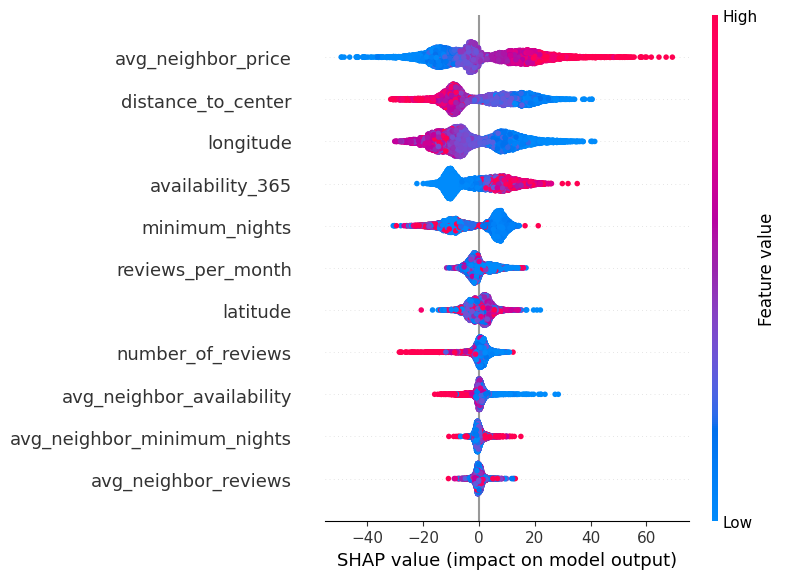

In [12]:
shap.summary_plot(shap_values,X_test)

**SHAP Feature Importance :**

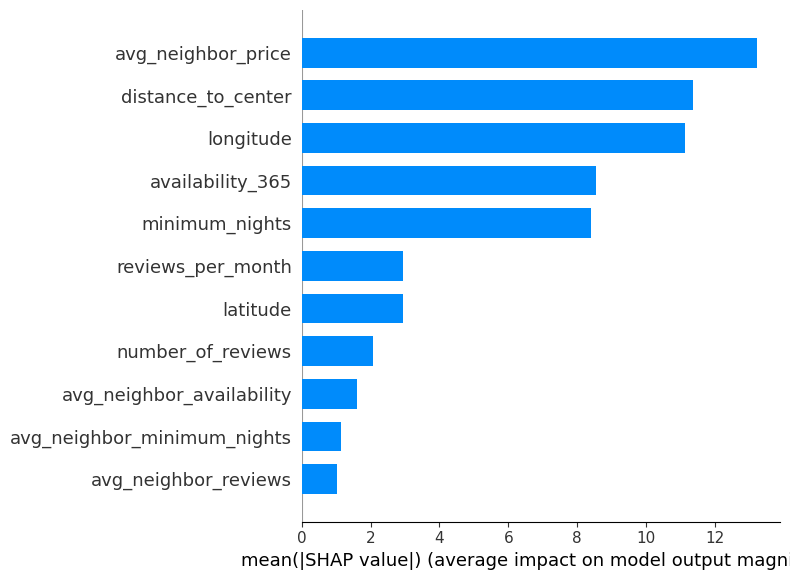

In [13]:
shap.summary_plot(shap_values,X_test,plot_type="bar")

**Prediction vs Actual :**

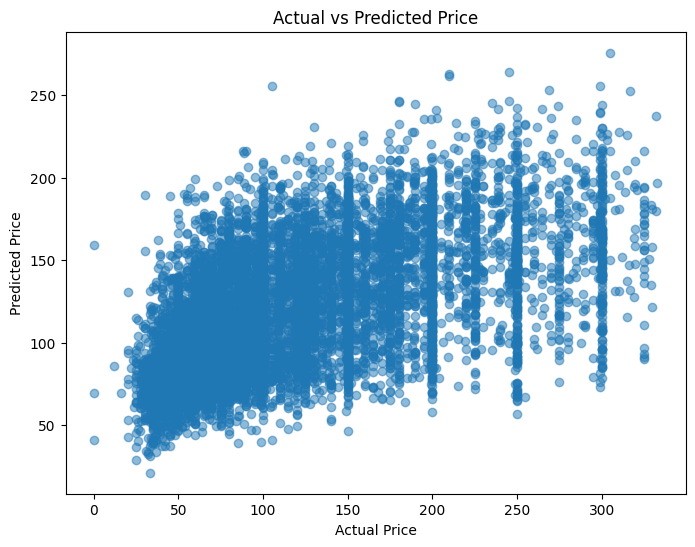

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(y_test,prediction,alpha=0.5)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

In [15]:
joblib.dump(model,"real_estate_price_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [16]:
results = pd.DataFrame({"Actual Price":y_test,"Predicted Price":prediction})

results.to_csv("week4_AB_NYC_2019.csv",index=False)